In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping


In [10]:
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_classes=2,
    random_state=42
)

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(20,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
early_stopper = EarlyStopping(
    monitor='val_loss',          # We monitor the validation loss
    min_delta=0.001,             # Minimum change to qualify as an improvement
    patience=10,                 # Tolerate 10 epochs with no improvement
    restore_best_weights=True,   # Revert to the best epoch's weights at the end
    verbose=1                    # Print a message when stopping occurs
)


In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopper]
)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8037 - loss: 0.4292 - val_accuracy: 0.8775 - val_loss: 0.3119
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9175 - loss: 0.2214 - val_accuracy: 0.9100 - val_loss: 0.2398
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9413 - loss: 0.1625 - val_accuracy: 0.9225 - val_loss: 0.2184
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9600 - loss: 0.1318 - val_accuracy: 0.9175 - val_loss: 0.2261
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9650 - loss: 0.1102 - val_accuracy: 0.9225 - val_loss: 0.2148
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9725 - loss: 0.0927 - val_accuracy: 0.9050 - val_loss: 0.2407
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9769 - loss: 0.0799 - val_accuracy: 0.9325 - val_loss: 0.2011
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0672 - val_accuracy: 0.9450 - v

In [19]:
early_stopper.best_epoch

7

In [20]:
early_stopper.best_weights

[array([[ 0.0790193 ,  0.05988662,  0.13053448, ...,  0.05293111,
          0.07097122,  0.08036991],
        [ 0.03504958, -0.05959872,  0.17403266, ..., -0.17784251,
         -0.11573672,  0.0181775 ],
        [ 0.16959125, -0.21170124, -0.13373631, ..., -0.00615589,
         -0.1748094 , -0.09894221],
        ...,
        [-0.17922333,  0.01458585, -0.16326727, ..., -0.01872137,
          0.05688743, -0.02635184],
        [ 0.00584911,  0.10799974, -0.178796  , ...,  0.14162809,
         -0.16247956,  0.08778513],
        [-0.21185197, -0.13622032,  0.10493273, ..., -0.17944036,
          0.00932279,  0.077018  ]], dtype=float32),
 array([ 0.01520726,  0.02706576, -0.02026063,  0.00289144,  0.04685939,
         0.03877208,  0.00304818,  0.03811251,  0.04740141, -0.01481859,
        -0.04331522, -0.02568255,  0.03464558,  0.00343228,  0.00533842,
         0.02097276,  0.01418107,  0.02573379, -0.0090163 , -0.0095465 ,
         0.0388736 ,  0.02887688, -0.00536397,  0.06101708, -0.007

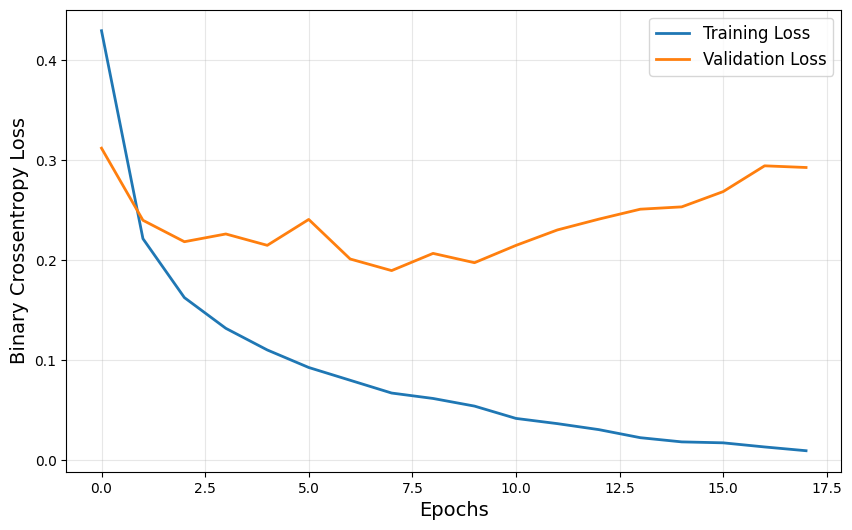

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Binary Crossentropy Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

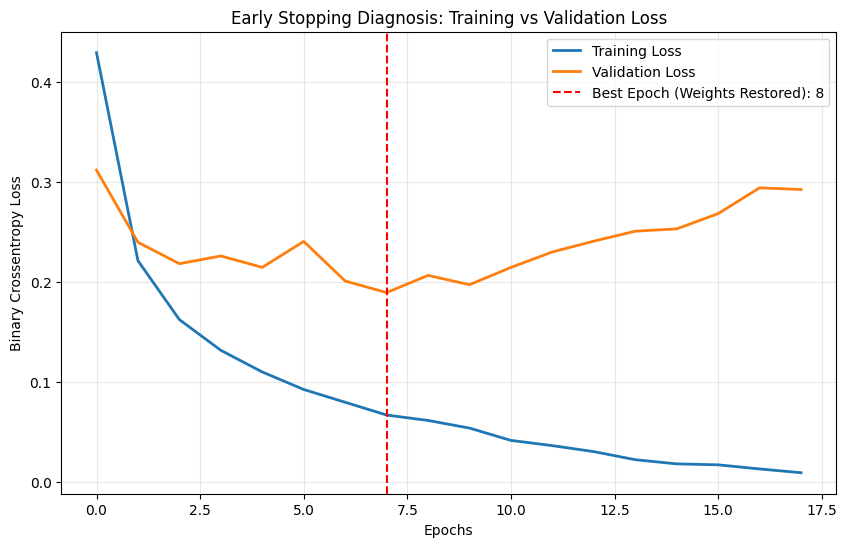

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

best_epoch = early_stopper.best_epoch
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch (Weights Restored): {best_epoch + 1}') # Loop starts from 0.

plt.title('Early Stopping Diagnosis: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()